┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574
┌ Warning: type Newtrinos.NewtrinosResult does not exist in workspace; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/pdSa4/src/data/reconstructing_datatypes.jl:574


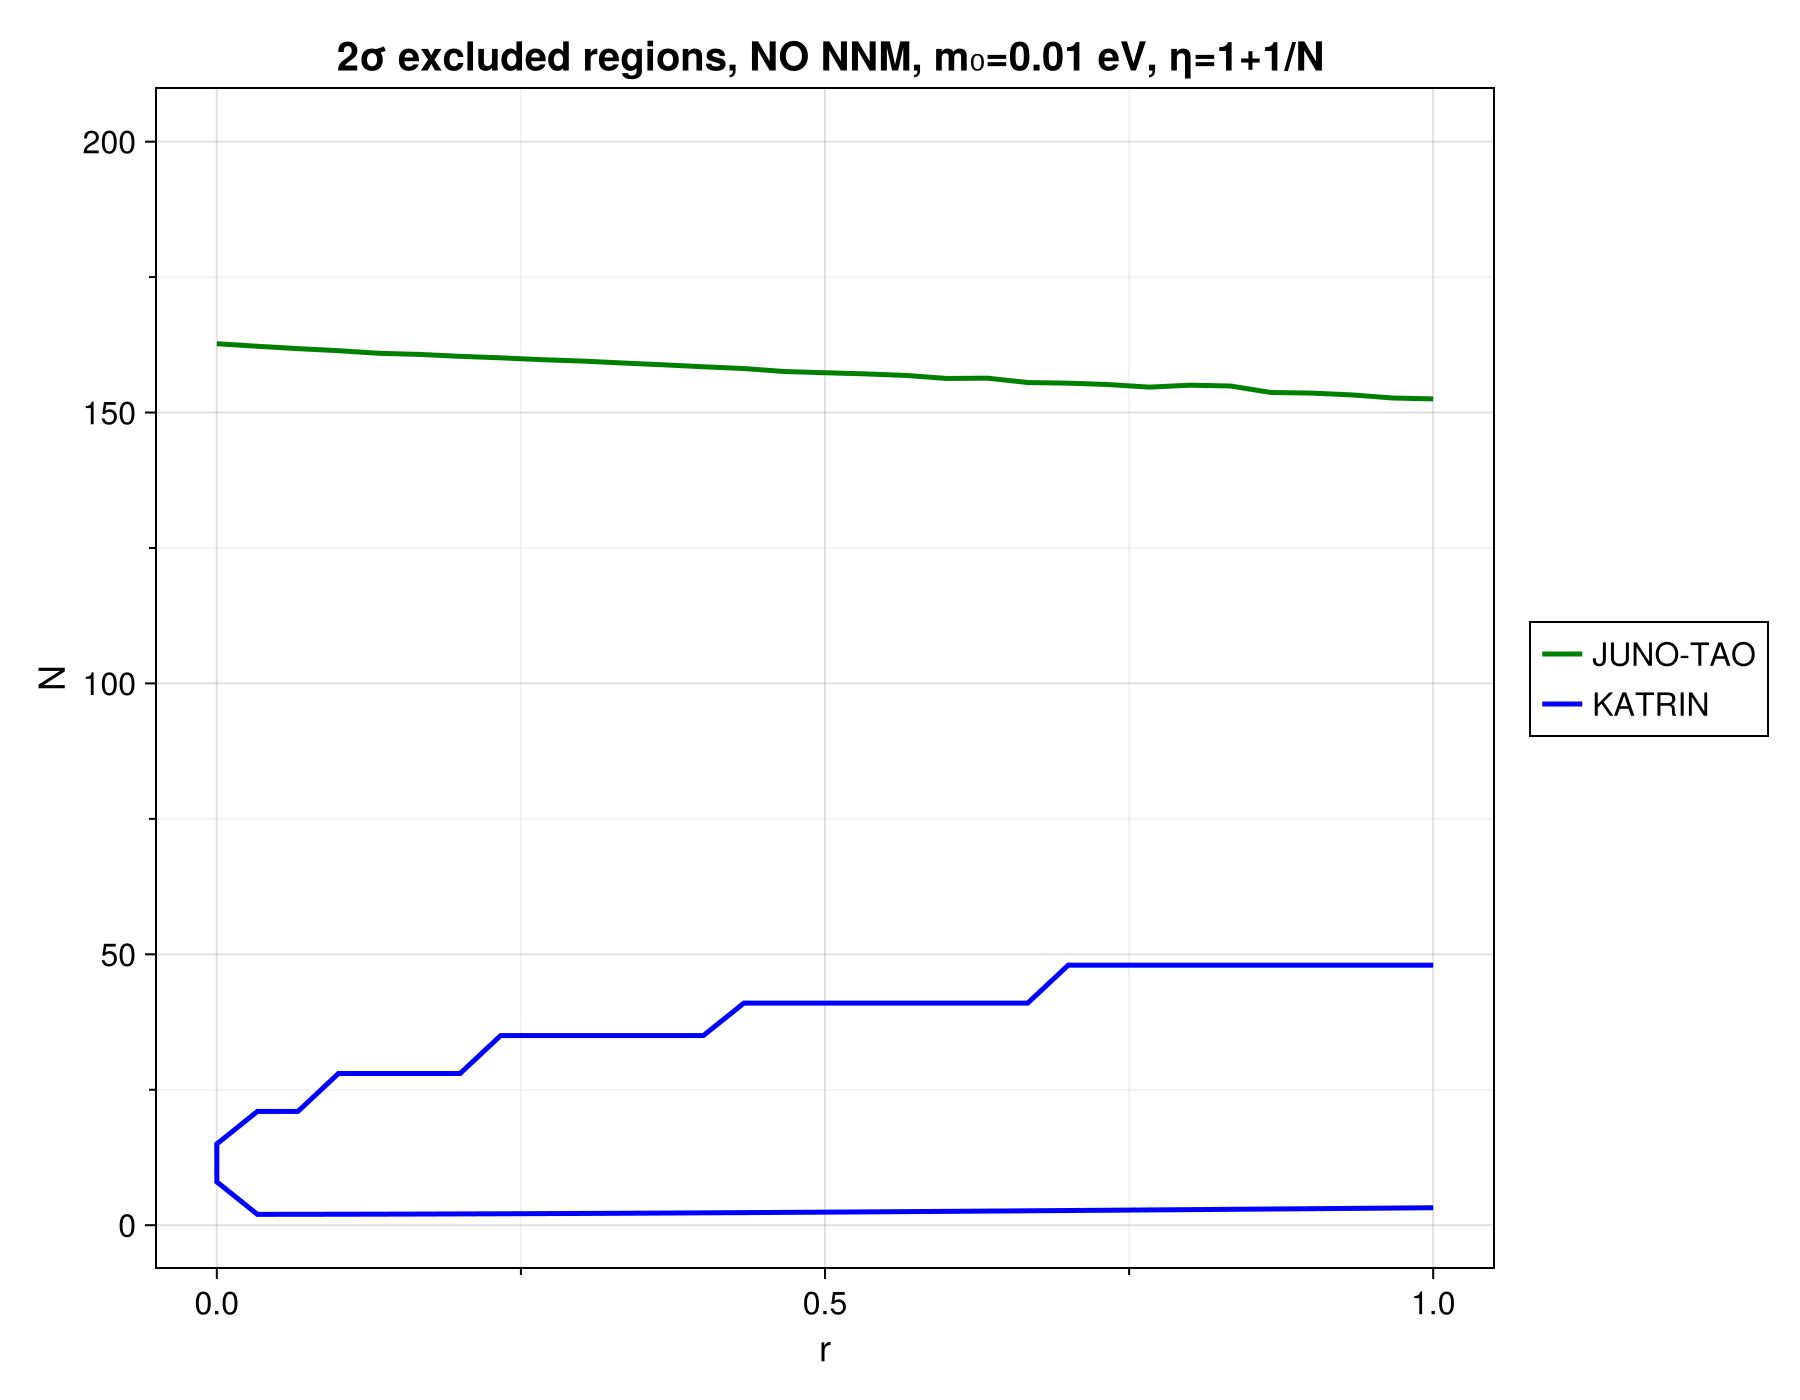

CairoMakie.Screen{IMAGE}


In [2]:
using JLD2, CairoMakie, Distributions

function superpose_contours(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colors=nothing,
                           linestyles=nothing)
 
    
    # Default colors and linestyles
    if colors === nothing
        colors = [:black, :red, :blue, :green, :orange, :purple, :brown, :pink]
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Calculate 2σ level
    sigma_2_level = quantile(Chisq(2), 1 - 2*ccdf(Normal(), 2))
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
    
    # Create figure
    f = Figure(size=(900, 700))
    ax = Axis(f[1,1];
        xlabel = xlabel,
        ylabel = ylabel,
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 20,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 16,
        yticklabelsize = 16,
    )
    
    # Plot contours
    legend_elements = []
    legend_labels = []
    
    for (idx, result) in enumerate(results)
        dLLH = 2 * (maximum(result.values.log_posterior) .- result.values.log_posterior)
        
        color = colors[mod(idx-1, length(colors)) + 1]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]
        
        contour!(ax, result.axes[1], result.axes[2], dLLH,
            levels = [sigma_2_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle)
        
        push!(legend_elements, LineElement(color=color, linewidth=2.5, linestyle=linestyle))
        push!(legend_labels, "File $idx")
        if experiments !== nothing && length(experiments) >= idx
            legend_labels[end] = experiments[idx]
        end
    end
    
    # Add legend
    Legend(f[1, 2],
        legend_elements,
        legend_labels,
        framevisible = true,
        labelsize = 16,
        rowgap = 5)
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/junotao/junotao_full_rN_NNM_NO_η=1+1_N_m0=0.01.jld2", "/home/sofialon/Newtrinos.jl/plots_fix/katrin/scan_katrin_Nr_m0=0.01_NNM_NO.jld2"]#"/home/sofialon/Newtrinos.jl/plots_fix/gerda/scan_gerda_Nr_m0=0.01_200_NNM_NO.jld2", "/home/sofialon/Newtrinos.jl/plots_fix/legend/scan_legend200_Nr_m0=0.01_200_NNM_NO.jld2", "/home/sofialon/Newtrinos.jl/plots_fix/legend/scan_legend1000_Nr_m0=0.01_200_NNM_NO.jld2" ]
colors = [:green,:blue,:red, :orange, :purple]
linestyles = [:solid,:solid,:solid, :solid , :solid]
fig = superpose_contours(file_paths;  title=" 2σ excluded regions, NO NNM, m₀=0.01 eV, η=1+1/N",
                           xlabel="r", 
                           ylabel="N", experiments = ["JUNO-TAO", "KATRIN"], colors=colors, linestyles=linestyles)
display(fig)
# save("superposed_contours.png", fig)